# LISTA 06 AMA

#### Aluno: Jônatas Fernandes Silva
#### Matrícula: 603243

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para os gráficos
sns.set_theme(style="whitegrid")
%matplotlib inline

#### Montando drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Carregando dados

In [3]:
df_quake = pd.read_csv('/content/penguins.csv', header=None)
df_penguins = pd.read_csv('/content/penguins.csv', header=None)

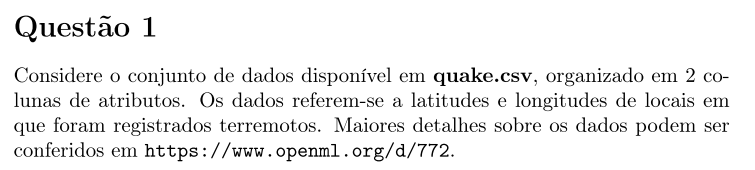

In [4]:
def normalize_zscore(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    std[std == 0] = 1e-8
    return (X - mean) / std

In [5]:
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def mahalanobis_distance(x, y, inv_cov):
    delta = x - y
    return np.sqrt(np.dot(np.dot(delta, inv_cov), delta.T))

def compute_db_index(X, labels, centroids, K, metric='euclidean', inv_cov=None):
    S = np.zeros(K)
    for k in range(K):
        cluster_points = X[labels == k]
        if len(cluster_points) == 0:
            S[k] = 0
            continue

        if metric == 'euclidean':
            dists = np.array([euclidean_distance(pt, centroids[k]) for pt in cluster_points])
        else:
            dists = np.array([mahalanobis_distance(pt, centroids[k], inv_cov) for pt in cluster_points])
        S[k] = np.mean(dists)

    R_max = np.zeros(K)
    for k in range(K):
        R_k = []
        for j in range(K):
            if j != k:
                if metric == 'euclidean':
                    M_kj = euclidean_distance(centroids[k], centroids[j])
                else:
                    M_kj = mahalanobis_distance(centroids[k], centroids[j], inv_cov)

                if M_kj == 0:
                    M_kj = 1e-8
                R_kj = (S[k] + S[j]) / M_kj
                R_k.append(R_kj)
        R_max[k] = np.max(R_k) if len(R_k) > 0 else 0

    return np.mean(R_max)

def kmeans(X, K, metric='euclidean', max_iters=100, inv_cov=None):
    N, D = X.shape
    # Inicialização aleatória dos centroides pegando K amostras distintas
    random_indices = np.random.choice(N, K, replace=False)
    centroids = X[random_indices].copy()

    labels = np.zeros(N)

    for _ in range(max_iters):
        old_centroids = centroids.copy()

        # Atribuição de clusters
        for i in range(N):
            distances = []
            for k in range(K):
                if metric == 'euclidean':
                    d = euclidean_distance(X[i], centroids[k])
                else:
                    d = mahalanobis_distance(X[i], centroids[k], inv_cov)
                distances.append(d)
            labels[i] = np.argmin(distances)

        # Atualização dos centroides
        for k in range(K):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                centroids[k] = np.mean(cluster_points, axis=0)

        # Critério de parada por convergência absoluta dos centroides
        if np.allclose(old_centroids, centroids):
            break

    # Cálculo do erro de reconstrução
    inertia = 0
    for i in range(N):
        if metric == 'euclidean':
            inertia += euclidean_distance(X[i], centroids[int(labels[i])]) ** 2
        else:
            inertia += mahalanobis_distance(X[i], centroids[int(labels[i])], inv_cov) ** 2

    return centroids, labels, inertia

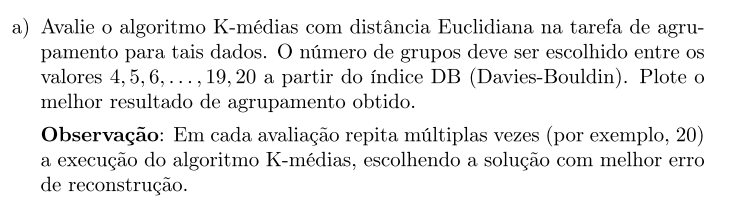

In [6]:
# Carregamento e Normalização
X_quake = df_quake.values
X_quake_norm = normalize_zscore(X_quake)

K_values = list(range(4, 21))
best_db_per_K_eucl = []
best_results_eucl = {}

print("Executando K-médias Euclidiano")
for K in K_values:
    best_inertia = float('inf')
    best_labels = None
    best_centroids = None

    for _ in range(20):
        centroids, labels, inertia = kmeans(X_quake_norm, K, metric='euclidean')
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centroids = centroids

    # Calcula o índice DB para a melhor execução deste K
    db_idx = compute_db_index(X_quake_norm, best_labels, best_centroids, K, metric='euclidean')
    best_db_per_K_eucl.append(db_idx)
    best_results_eucl[K] = (best_centroids, best_labels)

# Encontra o melhor K
best_K_eucl = K_values[np.argmin(best_db_per_K_eucl)]
print(f"Melhor K pelo índice DB (Euclidiana): {best_K_eucl}")
best_centroids, best_labels = best_results_eucl[best_K_eucl]

Executando K-médias Euclidiano
Melhor K pelo índice DB (Euclidiana): 4


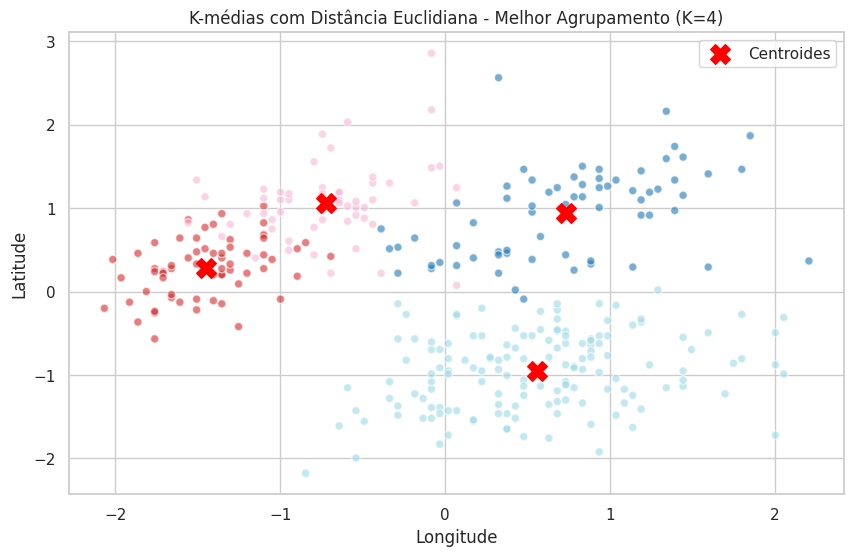

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(X_quake_norm[:, 1], X_quake_norm[:, 0], c=best_labels, cmap='tab20', alpha=0.6, edgecolors='w')
plt.scatter(best_centroids[:, 1], best_centroids[:, 0], c='red', marker='X', s=200, label='Centroides')
plt.title(f"K-médias com Distância Euclidiana - Melhor Agrupamento (K={best_K_eucl})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

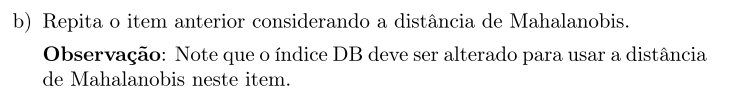

In [10]:
# Matriz de Covariância Global
cov_matrix = np.cov(X_quake_norm.T)
inv_cov_matrix = np.linalg.inv(cov_matrix)

best_db_per_K_maha = []
best_results_maha = {}

print("Executando K-médias Mahalanobis")
for K in K_values:
    best_inertia = float('inf')
    best_labels = None
    best_centroids = None

    for _ in range(20):
        centroids, labels, inertia = kmeans(X_quake_norm, K, metric='mahalanobis', inv_cov=inv_cov_matrix)
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centroids = centroids

    # Calcula o índice DB usando Mahalanobis
    db_idx = compute_db_index(X_quake_norm, best_labels, best_centroids, K, metric='mahalanobis', inv_cov=inv_cov_matrix)
    best_db_per_K_maha.append(db_idx)
    best_results_maha[K] = (best_centroids, best_labels)

# Encontra o melhor K
best_K_maha = K_values[np.argmin(best_db_per_K_maha)]
print(f"Melhor K pelo índice DB (Mahalanobis): {best_K_maha}")
best_centroids_m, best_labels_m = best_results_maha[best_K_maha]

Executando K-médias Mahalanobis
Melhor K pelo índice DB (Mahalanobis): 17


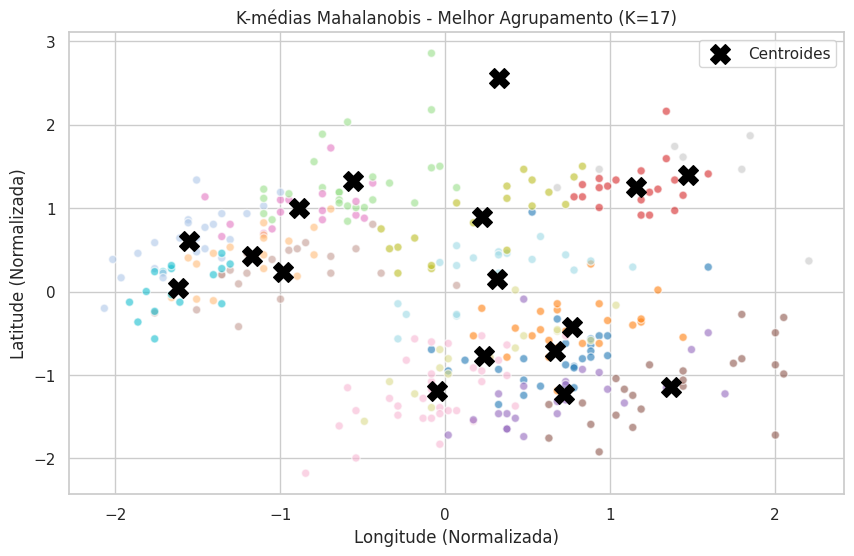

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X_quake_norm[:, 1], X_quake_norm[:, 0], c=best_labels_m, cmap='tab20', alpha=0.6, edgecolors='w')
plt.scatter(best_centroids_m[:, 1], best_centroids_m[:, 0], c='black', marker='X', s=200, label='Centroides')
plt.title(f"K-médias Mahalanobis - Melhor Agrupamento (K={best_K_maha})")
plt.xlabel("Longitude (Normalizada)")
plt.ylabel("Latitude (Normalizada)")
plt.legend()
plt.show()

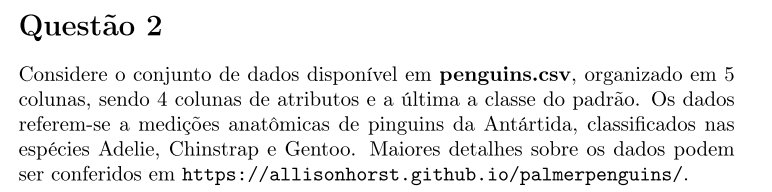

In [12]:
class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.singular_values = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        N, D = X.shape
        # O SVD recebe a matriz centralizada.
        U, S, Vt = np.linalg.svd(X, full_matrices=False)

        # Guardar os autovetores correspondentes
        self.components = Vt[:self.n_components]
        self.singular_values = S

        # Cálculo da variância explicada por meio dos valores singulares
        eigenvalues = (S ** 2) / (N - 1)
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues / total_variance

    def transform(self, X):
        # Projeta os dados originais no subespaço das componentes principais selecionadas
        return np.dot(X, self.components.T)

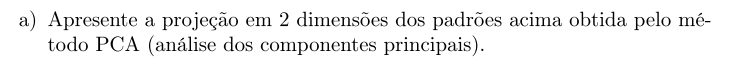

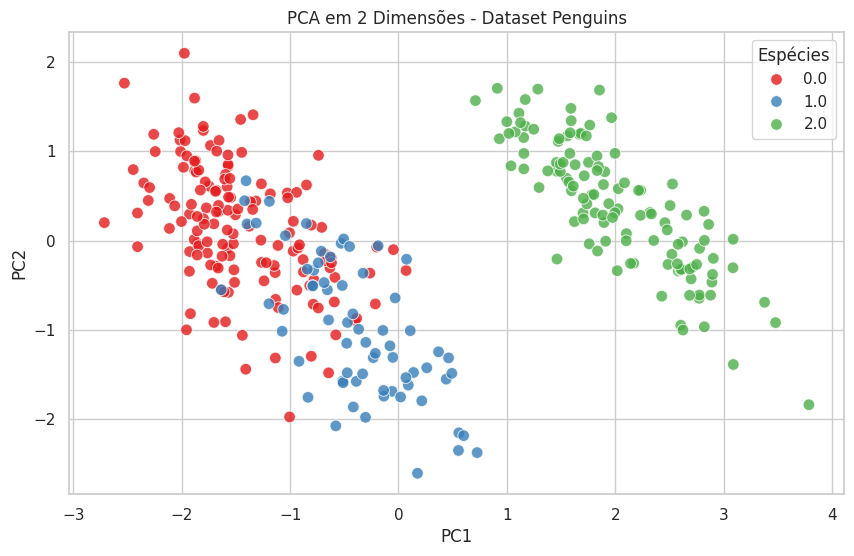

In [14]:
# Carregamento dos dados
X_penguins = df_penguins.iloc[:, :4].values
y_penguins = df_penguins.iloc[:, 4].values

# Normalização dos atributos
X_penguins_norm = normalize_zscore(X_penguins)

# Instancia e ajusta o PCA para 2 componentes
pca_2d = PCAFromScratch(n_components=2)
pca_2d.fit(X_penguins_norm)
X_projected = pca_2d.transform(X_penguins_norm)

# Gera Gráfico de Projeção 2D
plt.figure(figsize=(10, 6))

df_plot = pd.DataFrame(X_projected, columns=['PC1', 'PC2'])
df_plot['Espécie'] = y_penguins

sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Espécie', palette='Set1', s=70, alpha=0.8)
plt.title("PCA em 2 Dimensões - Dataset Penguins")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Espécies")
plt.show()

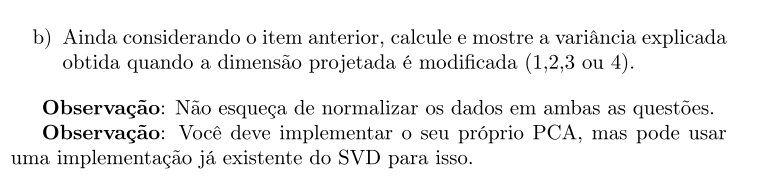

--- Variância Explicada por Dimensão ---
Dimensões = 1: Variância Acumulada = 68.63% (PC1 individual = 68.63%)
Dimensões = 2: Variância Acumulada = 88.09% (PC2 individual = 19.45%)
Dimensões = 3: Variância Acumulada = 97.30% (PC3 individual = 9.22%)
Dimensões = 4: Variância Acumulada = 100.00% (PC4 individual = 2.70%)


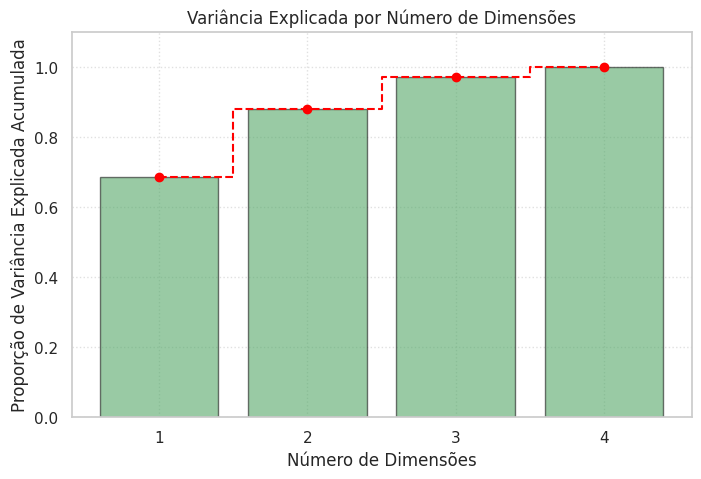

In [16]:
# Instancia o PCA com 4 componentes
pca_full = PCAFromScratch(n_components=4)
pca_full.fit(X_penguins_norm)

variances = pca_full.explained_variance_ratio_
cumulative_variances = np.cumsum(variances)

print("--- Variância Explicada por Dimensão ---")
for i in range(4):
    print(f"Dimensões = {i+1}: Variância Acumulada = {cumulative_variances[i]*100:.2f}% (PC{i+1} individual = {variances[i]*100:.2f}%)")

dims = ['1', '2', '3', '4']
plt.figure(figsize=(8, 5))
plt.bar(dims, cumulative_variances, alpha=0.6, color='g', edgecolor='k', label='Variância Acumulada')
plt.step(dims, cumulative_variances, where='mid', color='red', linestyle='--', marker='o')
plt.title("Variância Explicada por Número de Dimensões")
plt.xlabel("Número de Dimensões")
plt.ylabel("Proporção de Variância Explicada Acumulada")
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()